In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import dimod
from torch.utils.data import TensorDataset, DataLoader

In [2]:
class FeaturesEmbedding(torch.nn.Module):

    def __init__(self, field_dims, embed_dim):
        super().__init__()
        self.embedding = torch.nn.Embedding(sum(field_dims), embed_dim)
        self.offsets = np.array((0, *np.cumsum(field_dims)[:-1]), dtype=np.long)
        torch.nn.init.xavier_uniform_(self.embedding.weight.data)

    def forward(self, x):
        x = x + x.new_tensor(self.offsets).unsqueeze(0)
        return self.embedding(x)

class FeaturesLinear(torch.nn.Module):

    def __init__(self, field_dims, output_dim=1):
        super().__init__()
        self.fc = torch.nn.Embedding(sum(field_dims), output_dim)
        self.bias = torch.nn.Parameter(torch.zeros((output_dim,)))
        self.offsets = np.array((0, *np.cumsum(field_dims)[:-1]), dtype=np.long)

    def forward(self, x):
        x = x + x.new_tensor(self.offsets).unsqueeze(0)
        return torch.sum(self.fc(x), dim=1) + self.bias

class FactorizationMachine(torch.nn.Module):

    def __init__(self, reduce_sum=True):
        super().__init__()
        self.reduce_sum = reduce_sum

    def forward(self, x):
        square_of_sum = torch.sum(x, dim=1) ** 2
        sum_of_square = torch.sum(x ** 2, dim=1)
        ix = square_of_sum - sum_of_square
        if self.reduce_sum:
            ix = torch.sum(ix, dim=1, keepdim=True)
        return 0.5 * ix

class FactorizationMachineModel(torch.nn.Module):

    def __init__(self, field_dims, embed_dim):
        super().__init__()
        self.embedding = FeaturesEmbedding(field_dims, embed_dim)
        self.linear = FeaturesLinear(field_dims)
        self.fm = FactorizationMachine(reduce_sum=True)

    def forward(self, x):
        x = self.linear(x) + self.fm(self.embedding(x))
        return x.squeeze(1)

Using device: cuda
Epoch [100/1000], Loss: 0.1214
Epoch [200/1000], Loss: 0.0015
Epoch [300/1000], Loss: 0.0001
Epoch [400/1000], Loss: 0.0013
Epoch [500/1000], Loss: 0.0005
Epoch [600/1000], Loss: 0.0001
Epoch [700/1000], Loss: 0.0003
Epoch [800/1000], Loss: 0.0001
Epoch [900/1000], Loss: 0.0003
Epoch [1000/1000], Loss: 0.0002


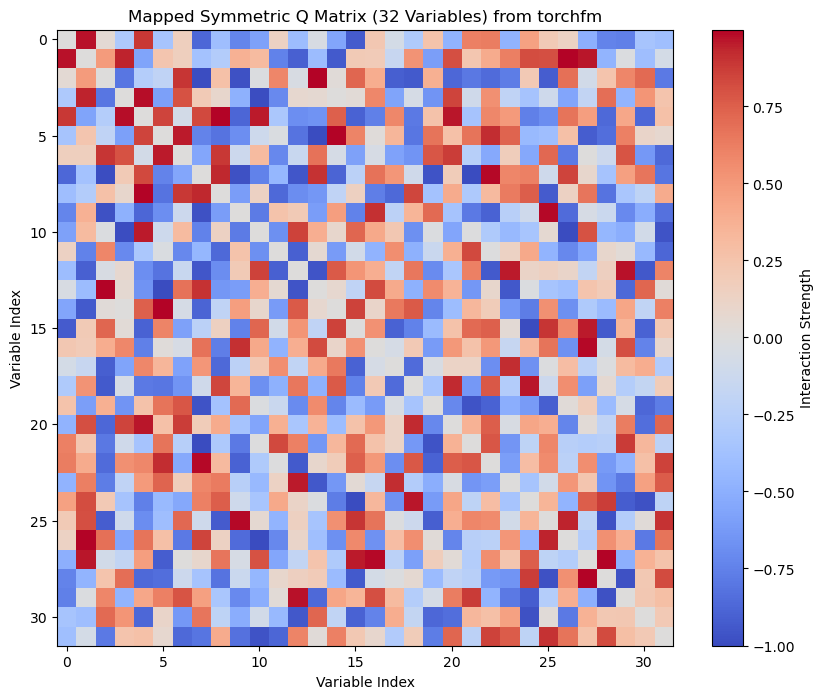

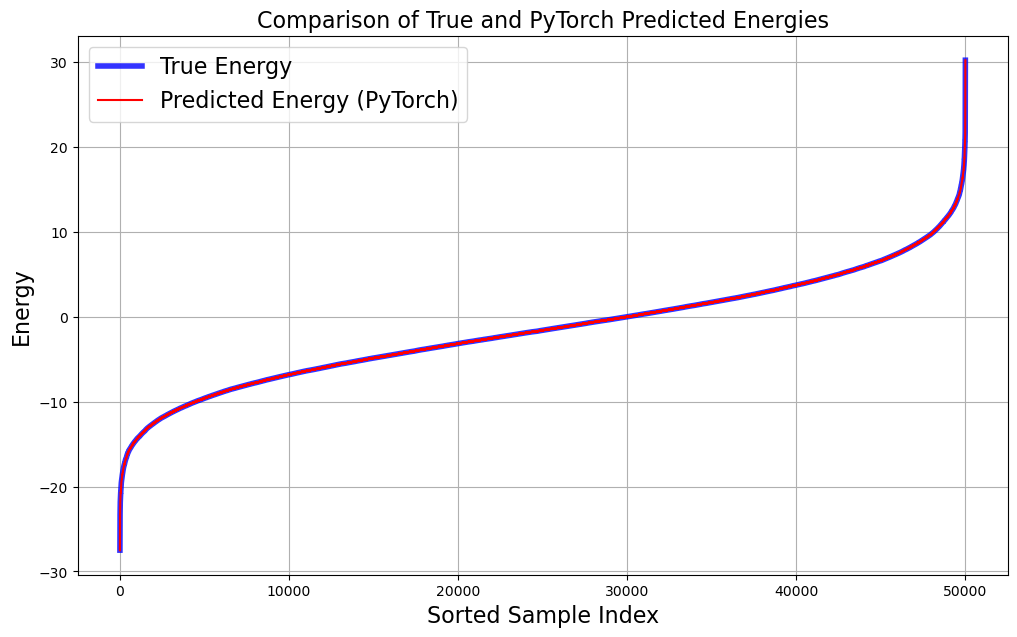

In [3]:
DATASET_SIZE = 10000
TEST_NUM = 50000
RANDOM_SEED = 42
VAR_NUM = 32
K = VAR_NUM
NUM_EPOCH = 1000
LEARNING_RATE = 1e-3
BATCH_SIZE = 512
FIELD_DIMS = [2] * VAR_NUM

def custom_bias_generator(var_num):
    return np.random.uniform(-1, 1, var_num)

bqm = dimod.generators.gnm_random_bqm(
          variables=VAR_NUM,
          num_interactions=VAR_NUM*(VAR_NUM-1)/2,
          vartype=dimod.BINARY,
          bias_generator=custom_bias_generator
      )

xs_train = np.random.randint(0, 2, (DATASET_SIZE, VAR_NUM), dtype=np.int8)
ys_train = np.array([bqm.energy(x) for x in xs_train], dtype=np.float64)
xs_test = np.random.randint(0, 2, (TEST_NUM, VAR_NUM), dtype=np.int8)
ys_test = np.array([bqm.energy(x) for x in xs_test], dtype=np.float64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_py = FactorizationMachineModel(field_dims=FIELD_DIMS, embed_dim=K)
model_py.to(device)

x_tensor = torch.from_numpy(xs_train).long()
y_tensor = torch.from_numpy(ys_train).float()
train_dataset = TensorDataset(x_tensor, y_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_py.parameters(), lr=LEARNING_RATE)

model_py.train()
for epoch in range(NUM_EPOCH):
    total_loss = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_py(inputs)
        loss = criterion(outputs.squeeze(), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCH}], Loss: {total_loss / len(train_loader):.4f}')

def fm_to_bqm(model, var_num, device='cpu'):
    model.eval()
    model.to(device)

    def predict(x_np):
        x = torch.tensor(x_np, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            return model(x).item()

    base = np.zeros(var_num, dtype=np.int64)
    b = predict(base)
    f_ei = np.array([predict(base + np.eye(var_num, dtype=np.int64)[i]) for i in range(var_num)])
    h = f_ei - b
    Q = np.zeros((var_num, var_num))
  
    for i in range(var_num):
      
        for j in range(i + 1, var_num):
            x_ij = base.copy()
            x_ij[i] = 1
            x_ij[j] = 1
            Q[i, j] = predict(x_ij) - f_ei[i] - f_ei[j] + b

    h_dict = {i: float(h[i]) for i in range(var_num)}
    Q_dict = {(i, j): float(Q[i, j]) for i in range(var_num) for j in range(i+1, var_num)}
    bqm_pred = dimod.BinaryQuadraticModel(h_dict, Q_dict, float(b), dimod.BINARY)
    Q += Q.T
    return bqm_pred, Q

bqm_pytorch, Q_pytorch = fm_to_bqm(model_py, VAR_NUM)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(Q_pytorch, cmap='coolwarm', interpolation='nearest')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Interaction Strength')
ax.set_title("Mapped Symmetric Q Matrix (32 Variables) from torchfm")
ax.set_xlabel("Variable Index")
ax.set_ylabel("Variable Index")

ys_pred_pytorch = np.array([bqm_pytorch.energy(x) for x in xs_test], dtype=np.float64)
sorted_indices = np.argsort(ys_test)
ys_sorted = ys_test[sorted_indices]
ys_pred_pt_sorted = ys_pred_pytorch[sorted_indices]

plt.figure(figsize=(12, 7))
plt.plot(ys_sorted, color="blue", label="True Energy", linewidth=4, alpha=0.8)
plt.plot(ys_pred_pt_sorted, color="red", label="Predicted Energy (PyTorch)", linestyle='-')
plt.title("Comparison of True and PyTorch Predicted Energies", fontsize=16)
plt.xlabel("Sorted Sample Index", fontsize=16)
plt.ylabel("Energy", fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.show()